In [7]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [6]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
adult=fetch_ucirepo(id=2)
x=adult.data.features
y=adult.data.targets
df=pd.concat([x,y],axis=1)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
df.info()
df.isnull().sum()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


(48842, 15)

In [9]:
df['workclass'] = df['workclass'].replace('?', np.nan)
df['workclass'] = df['workclass'].fillna('Unknown')

In [ ]:
df['occupation'] = df['occupation'].replace('?', np.nan)
df['occupation'] = df['occupation'].fillna('Unknown')

In [ ]:
df['native-country'] = df['native-country'].replace('?', np.nan)
df['native-country'] = df['native-country'].fillna('Unknown')

In [ ]:
df['capital-gain'] = X['capital-gain']
df['capital-gain-capped'] = (df['capital-gain'] == 99999).astype(int)

In [10]:
df['income'] = df['income'].str.replace('.', '', regex=False)
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

education
HS-grad         0.323164
Some-college    0.222718
Bachelors       0.164305
Masters         0.054400
Assoc-voc       0.042197
11th            0.037099
Assoc-acdm      0.032779
10th            0.028439
7th-8th         0.019553
Prof-school     0.017075
9th             0.015478
12th            0.013452
Doctorate       0.012162
5th-6th         0.010421
1st-4th         0.005057
Preschool       0.001699
Name: proportion, dtype: float64


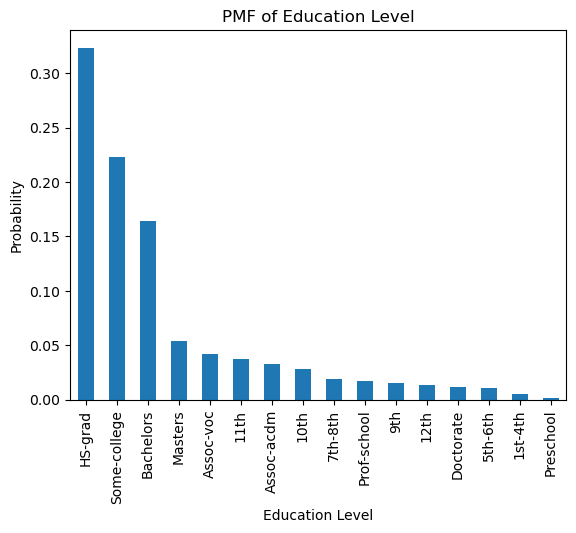

In [11]:
pmf_education = df['education'].value_counts(normalize=True)
print(pmf_education)
pmf_education.plot(kind='bar')
plt.xlabel('Education Level')
plt.ylabel('Probability')
plt.title('PMF of Education Level')
plt.show()

In [13]:
from scipy import stats

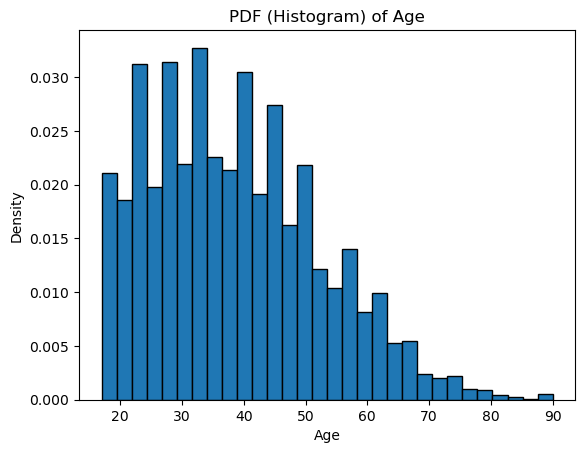

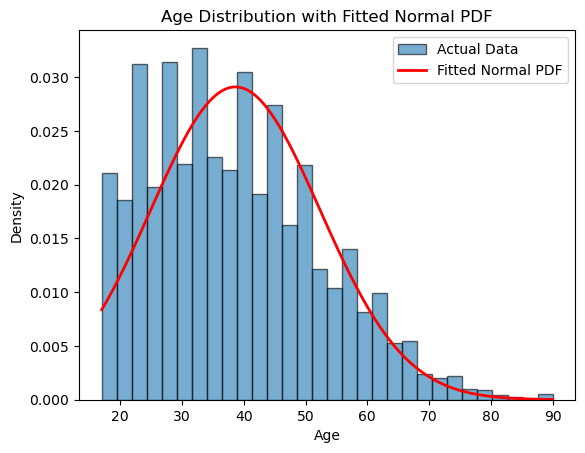

Mean (mu): 38.64
Standard deviation (std): 13.71
Skewness of age: 0.558
Median: 37.00


In [14]:
df['age'].plot(kind='hist', bins=30, density=True, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('PDF (Histogram) of Age')
plt.show()

data = df['age']
mu, std = stats.norm.fit(data)
x = np.linspace(data.min(), data.max(), 100)
pdf_fitted = stats.norm.pdf(x, mu, std)

plt.hist(data, bins=30, density=True, alpha=0.6, edgecolor='black', label='Actual Data')
plt.plot(x, pdf_fitted, 'r-', linewidth=2, label='Fitted Normal PDF')
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age Distribution with Fitted Normal PDF')
plt.legend()
plt.show()

print(f"Mean (mu): {mu:.2f}")
print(f"Standard deviation (std): {std:.2f}")
print(f"Skewness of age: {skew(df['age']):.3f}")
print(f"Median: {df['age'].median():.2f}")

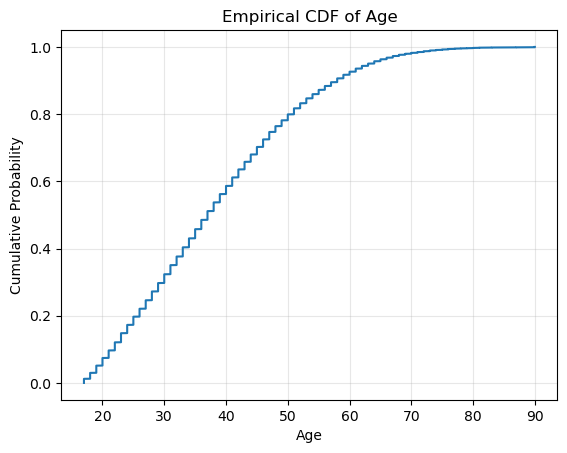

56.19% of individuals are under 40 years old


In [15]:
data_sorted = np.sort(df['age'])
cdf_values = np.arange(1, len(data_sorted) + 1) / len(data_sorted)

plt.plot(data_sorted, cdf_values)
plt.xlabel('Age')
plt.ylabel('Cumulative Probability')
plt.title('Empirical CDF of Age')
plt.grid(True, alpha=0.3)
plt.show()

percent_under_40 = (df['age'] < 40).mean() * 100
print(f"{percent_under_40:.2f}% of individuals are under 40 years old")